# Polynomial NARX Model — Greenhouse System Identification

This notebook extends the linear ARX baseline with **polynomial features** (squared terms, cross-terms) to investigate whether **non-linear regressors** can improve prediction quality, especially in free-run simulation where error accumulation is the primary challenge.

**Key idea:** NARX is still estimated by OLS (linear in parameters, non-linear in inputs).

## 1. Configuration & Imports

In [1]:
from __future__ import annotations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.diagnostic import acorr_ljungbox
from IPython.display import display, Markdown

# Pipeline modules
from arx_pipeline import (
    DataConfig, SplitConfig, ModelConfig,
    load_or_generate_data, split_time_series,
    build_regression_matrix, estimate_ols, compute_metrics,
    simulate_arx, simulate_arx_n_step,
    summarize_parameters, compute_ar_roots, build_true_theta,
    residual_diagnostics, parameter_reference_map,
)
from narx_pipeline import (
    NARXModelConfig,
    build_narx_regression_matrix, get_narx_feature_names,
    simulate_narx, simulate_narx_n_step,
    evaluate_narx_slice, narx_model_selection,
    run_narx_pipeline, print_narx_summary,
)

plt.rcParams.update({'figure.dpi': 110, 'font.size': 11, 'axes.titlesize': 12})


def display_research_note(title, bullets):
    md = f'### {title}\n\n'
    for b in bullets:
        md += f'- {b}\n'
    display(Markdown(md))

print('Imports OK')

Imports OK


In [2]:
# ---- Configuration ----
DATA_CONFIG = DataConfig(
    csv_path=__import__('pathlib').Path('greenhouse_data.csv'),
    force_regenerate_from_script=False,
)
SPLIT_CONFIG = SplitConfig(train_ratio=0.60, val_ratio=0.20)

# NARX configuration
NARX_CONFIG = NARXModelConfig(
    na=2, nb=2, nk=1,
    poly_degree=2,
    include_intercept=True,
    cross_term_mode='selective',
    simulation_clip=(0.0, 100.0),
)

# ARX baseline config (for comparison)
ARX_CONFIG = NARX_CONFIG.linear_config

print(f'NARX: na={NARX_CONFIG.na}, nb={NARX_CONFIG.nb}, nk={NARX_CONFIG.nk}, degree={NARX_CONFIG.poly_degree}')
print(f'ARX:  na={ARX_CONFIG.na}, nb={ARX_CONFIG.nb}, nk={ARX_CONFIG.nk} (baseline)')

NARX: na=2, nb=2, nk=1, degree=2
ARX:  na=2, nb=2, nk=1 (baseline)


## 2. Data Loading & Characterization

In [3]:
# Load data
df, true_params, data_source = load_or_generate_data(DATA_CONFIG)
df_train, df_val, df_test = split_time_series(df, SPLIT_CONFIG)

print(f'Data source: {data_source}')
print(f'Total rows:  {len(df)}')
print(f'Train: {len(df_train)} | Val: {len(df_val)} | Test: {len(df_test)}')
print(f'Date range: {df["Timestamp"].iloc[0]} -> {df["Timestamp"].iloc[-1]}')
print(f'Months: {sorted(df["Month"].unique())}')

if true_params:
    print(f'\nTrue parameters from generator:')
    for k, v in true_params.items():
        print(f'  {k}: {v}')

Data source: CSV:greenhouse_data.csv
Total rows:  105120
Train: 63072 | Val: 21024 | Test: 21024
Date range: 2025-01-01 00:00:00 -> 2025-12-31 23:55:00
Months: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12)]

True parameters from generator:
  a1: 0.965
  a2: 0.025
  b_temp_1: -0.008
  b_temp_2: -0.004
  b_humi_1: 0.0025
  b_humi_2: 0.0012
  b_light_1: -0.00022
  b_light_2: -0.0001
  b_drip_1: 1.25
  b_drip_2: 1.85
  b_mist_1: 0.05
  b_mist_2: 0.03
  b_fan_1: -0.05
  b_fan_2: -0.03
  b_temp: -0.008
  b_humi: 0.0025
  b_light: -0.00022
  b_drip: 1.25
  b_mist: 0.05
  b_fan: -0.05
  noise_sigma: 0.25


In [4]:
# Monthly statistics
monthly = df.groupby('Month').agg({
    'Soil_Moisture': ['mean', 'std', 'min', 'max'],
    'Temperature': ['mean', 'std'],
    'Humidity': ['mean', 'std'],
    'Drip': 'mean',
    'Fan': 'mean',
}).round(2)
display(monthly)

display_research_note('Dataset overview', [
    f'Full-year dataset: {len(df)} samples at 5-minute intervals',
    f'Soil_Moisture range: {df["Soil_Moisture"].min():.1f} – {df["Soil_Moisture"].max():.1f} %',
    f'noise_sigma from generator: {true_params.get("noise_sigma", "unknown")}',
])

Soil_Moisture                     Temperature       Humidity        \
               mean   std    min    max        mean   std     mean   std   
Month                                                                      
1             54.63  2.85  48.71  64.31       23.99  4.42    74.79  7.60   
2             55.54  2.83  49.65  66.59       24.68  3.93    74.46  7.63   
3             56.48  2.81  50.14  66.19       25.09  3.83    74.50  7.65   
4             57.40  2.80  51.44  67.39       25.45  3.59    74.21  7.88   
5             58.31  2.80  52.18  68.85       26.29  2.99    72.97  8.45   
6             59.25  2.75  52.90  68.16       26.65  2.67    72.16  8.61   
7             60.16  2.76  54.11  69.95       27.10  2.22    71.97  7.99   
8             59.23  2.78  53.00  69.15       26.66  2.60    72.20  8.34   
9             57.36  2.79  51.58  66.56       26.54  2.63    72.27  8.42   
10            56.46  2.80  50.72  65.73       25.96  3.17    73.34  7.87   
11            55.50  2.82  49.28  65.82       25.48  3.48    73.69  7.80   
12            54.64  2.85  48.06  64.63       24.39  4.14    74.26  7.46   

       Drip   Fan  
       mean  mean  
Month              
1      0.21  0.14  
2      0.22  0.13  
3      0.22  0.16  
4      0.23  0.16  
5      0.24  0.20  
6      0.24  0.19  
7      0.25  0.22  
8      0.24  0.20  
9      0.23  0.19  
10     0.23  0.17  
11     0.22  0.15  
12     0.21  0.11

### Dataset overview

- Full-year dataset: 105120 samples at 5-minute intervals
- Soil_Moisture range: 48.1 – 70.0 %
- noise_sigma from generator: 0.25


## 3. NARX Model — Theory

### Linear ARX (baseline)
$$y(t) = \sum_{i=1}^{n_a} a_i \cdot y(t-i) + \sum_{j} \sum_{k=1}^{n_b} b_{j,k} \cdot u_j(t-n_k-k+1) + e(t)$$

All terms are **linear** in both parameters and regressors.

### Polynomial NARX
$$y(t) = \underbrace{\sum a_i \cdot y(t-i) + \sum b_{j,k} \cdot u_j(t-k)}_{\text{linear terms}} + \underbrace{\sum c_m \cdot \phi_m(y, u)}_{\text{polynomial terms}} + e(t)$$

where $\phi_m$ are **polynomial features** such as:
- $y(t-1)^2$ — non-linear autoregressive memory
- $y(t-1) \times \text{Drip}(t-1)$ — interaction between soil state and watering
- $\text{Temperature}(t-1)^2$ — non-linear temperature effect

**Key advantage:** Still linear in parameters → OLS estimation works!  
**Key risk:** More parameters → potential overfitting, higher condition number.

## 4. Feature Engineering

In [5]:
# Show all features
feature_names = get_narx_feature_names(NARX_CONFIG)
n_linear = NARX_CONFIG.na + NARX_CONFIG.nb * len(NARX_CONFIG.input_cols)
n_poly = len(feature_names) - n_linear - (1 if NARX_CONFIG.include_intercept else 0)

print(f'=== Feature Summary ===')
print(f'Linear features:     {n_linear}')
print(f'Polynomial features: {n_poly}')
print(f'Intercept:           {1 if NARX_CONFIG.include_intercept else 0}')
print(f'TOTAL:               {len(feature_names)}')
print(f'\nARX baseline had:    {len(ARX_CONFIG.param_names)} features')
print(f'Feature expansion:   {len(feature_names)/len(ARX_CONFIG.param_names):.1f}x')
print()
print('=== Linear Features ===')
for i, name in enumerate(feature_names[:n_linear]):
    print(f'  [{i:2d}] {name}')
print(f'\n=== Polynomial Features ===')
for i, name in enumerate(feature_names[n_linear:-1] if NARX_CONFIG.include_intercept else feature_names[n_linear:]):
    print(f'  [{n_linear+i:2d}] {name}')
if NARX_CONFIG.include_intercept:
    print(f'  [{len(feature_names)-1:2d}] intercept')

=== Feature Summary ===
Linear features:     14
Polynomial features: 32
Intercept:           1
TOTAL:               47

ARX baseline had:    14 features
Feature expansion:   3.4x

=== Linear Features ===
  [ 0] y(t-1)
  [ 1] y(t-2)
  [ 2] Temperature(t-1)
  [ 3] Temperature(t-2)
  [ 4] Humidity(t-1)
  [ 5] Humidity(t-2)
  [ 6] Light(t-1)
  [ 7] Light(t-2)
  [ 8] Drip(t-1)
  [ 9] Drip(t-2)
  [10] Mist(t-1)
  [11] Mist(t-2)
  [12] Fan(t-1)
  [13] Fan(t-2)

=== Polynomial Features ===
  [14] y(t-1)^2
  [15] y(t-2)^2
  [16] Temperature(t-1)^2
  [17] Temperature(t-2)^2
  [18] Humidity(t-1)^2
  [19] Humidity(t-2)^2
  [20] Light(t-1)^2
  [21] Light(t-2)^2
  [22] y(t-1)*Drip(t-1)
  [23] y(t-1)*Drip(t-2)
  [24] y(t-1)*Mist(t-1)
  [25] y(t-1)*Mist(t-2)
  [26] y(t-1)*Fan(t-1)
  [27] y(t-1)*Fan(t-2)
  [28] y(t-2)*Drip(t-1)
  [29] y(t-2)*Drip(t-2)
  [30] y(t-2)*Mist(t-1)
  [31] y(t-2)*Mist(t-2)
  [32] y(t-2)*Fan(t-1)
  [33] y(t-2)*Fan(t-2)
  [34] y(t-1)*Temperature(t-1)
  [35] y(t-1)*Temperature(t-

In [6]:
display_research_note('Feature engineering rationale', [
    f'Selective cross-term mode: only y-lag × input and y-lag² / continuous² terms are included.',
    f'This avoids feature explosion: "all" mode would produce {n_linear*(n_linear+1)//2} polynomial terms.',
    f'Selective mode produces {n_poly} polynomial terms — a {n_poly/(n_linear*(n_linear+1)//2)*100:.0f}% reduction.',
    'Binary inputs (Drip/Mist/Fan) are not squared (0²=0, 1²=1 = same as original).',
    'Cross-terms like y(t-1)×Drip(t-1) capture state-dependent watering effects.',
])

### Feature engineering rationale

- Selective cross-term mode: only y-lag × input and y-lag² / continuous² terms are included.
- This avoids feature explosion: "all" mode would produce 105 polynomial terms.
- Selective mode produces 32 polynomial terms — a 30% reduction.
- Binary inputs (Drip/Mist/Fan) are not squared (0²=0, 1²=1 = same as original).
- Cross-terms like y(t-1)×Drip(t-1) capture state-dependent watering effects.


## 5. Model Estimation

In [7]:
# === NARX estimation ===
X_narx_train, y_narx_train = build_narx_regression_matrix(df_train, NARX_CONFIG)
theta_narx, cov_narx, sigma2_narx = estimate_ols(X_narx_train, y_narx_train)

# === ARX estimation (baseline) ===
X_arx_train, y_arx_train = build_regression_matrix(df_train, ARX_CONFIG)
theta_arx, cov_arx, sigma2_arx = estimate_ols(X_arx_train, y_arx_train)
true_theta_arx = build_true_theta(true_params, ARX_CONFIG)

# Condition numbers
cond_narx = np.linalg.cond(X_narx_train.T @ X_narx_train)
cond_arx = np.linalg.cond(X_arx_train.T @ X_arx_train)

print('=== Estimation Results ===')
print(f'NARX: {len(theta_narx)} parameters, σ² = {sigma2_narx:.6f}, cond(X\'X) = {cond_narx:.2e}')
print(f'ARX:  {len(theta_arx)} parameters, σ² = {sigma2_arx:.6f}, cond(X\'X) = {cond_arx:.2e}')
print(f'\nσ² reduction: {(1 - sigma2_narx/sigma2_arx)*100:.2f}%')

=== Estimation Results ===
NARX: 47 parameters, σ² = 0.062474, cond(X'X) = 6.95e+16
ARX:  14 parameters, σ² = 0.062480, cond(X'X) = 5.63e+07

σ² reduction: 0.01%


## 6. Parameter Analysis

In [8]:
# NARX parameters table
std_narx = np.sqrt(np.diag(cov_narx))
param_df = pd.DataFrame({
    'Feature': feature_names,
    'Estimate': theta_narx,
    'Std Error': std_narx,
    'CI95 Low': theta_narx - 1.96 * std_narx,
    'CI95 High': theta_narx + 1.96 * std_narx,
    '|t-stat|': np.abs(theta_narx / std_narx),
    'Significant (p<0.05)': np.abs(theta_narx / std_narx) > 1.96,
})

print(f'=== NARX Parameters ({len(theta_narx)} total) ===')
print(f'Significant (|t| > 1.96): {param_df["Significant (p<0.05)"].sum()} / {len(theta_narx)}')
print()
display(param_df.round(6))

=== NARX Parameters (47 total) ===
Significant (|t| > 1.96): 11 / 47



,Feature,Estimate,Std Error,CI95 Low,CI95 High,|t-stat|,Significant (p<0.05)
0,y(t-1),0.895235,0.030123,0.836194,0.954277,29.719102,True
1,y(t-2),0.085458,0.030309,0.026051,0.144865,2.819514,True
2,Temperature(t-1),-0.100617,0.016503,-0.132963,-0.068271,6.096852,True
3,Temperature(t-2),0.085396,0.017403,0.051287,0.119505,4.907045,True
4,Humidity(t-1),0.013057,0.007053,-0.000767,0.026882,1.851192,False
5,Humidity(t-2),-0.008907,0.007076,-0.022777,0.004963,1.258670,False
6,Light(t-1),-0.001825,0.001221,-0.004219,0.000569,1.494498,False
7,Light(t-2),0.001648,0.001228,-0.000759,0.004055,1.341669,False
8,Drip(t-1),1.324736,0.029018,1.267861,1.381610,45.652689,True
9,Drip(t-2),1.859727,0.038679,1.783917,1.935538,48.081274,True


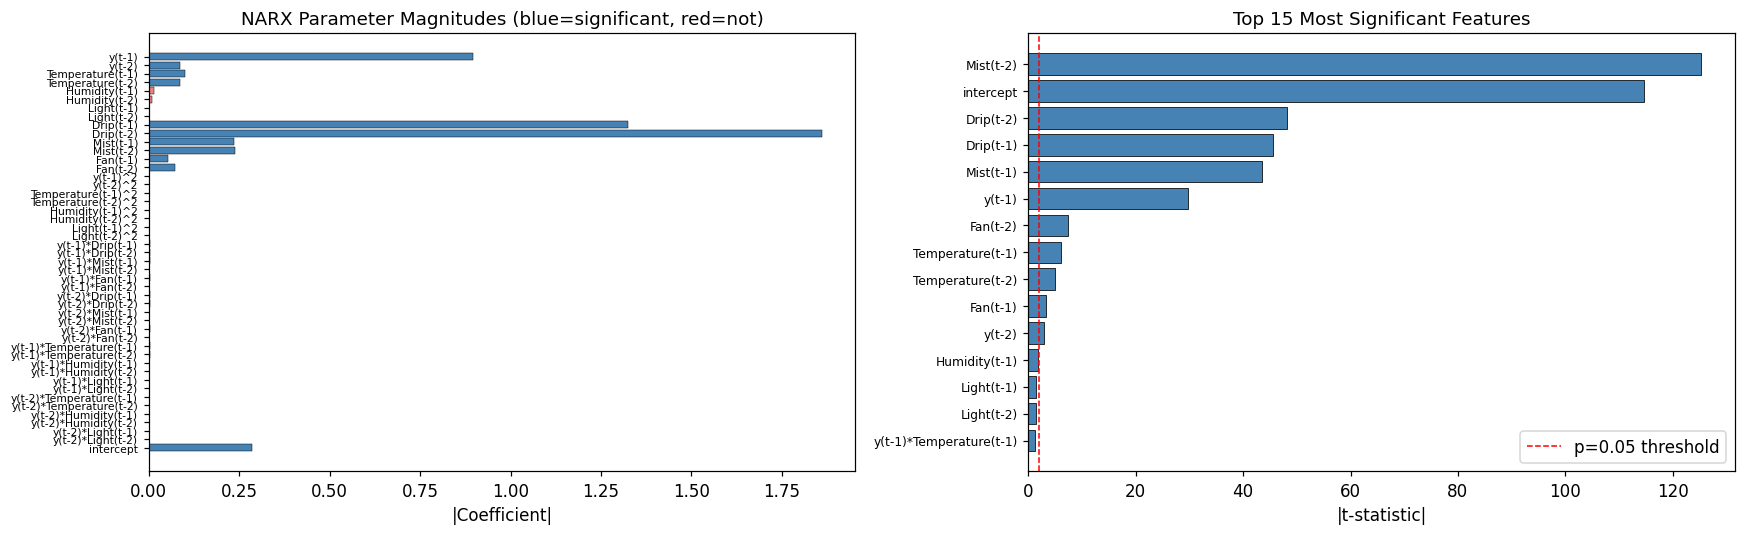

### Parameter analysis

- 11/47 parameters are statistically significant at p<0.05.
- The linear terms (y-lags, Drip, Temperature) remain the dominant features.
- Polynomial terms provide fine adjustments — their magnitudes are typically much smaller.
- Non-significant polynomial terms suggest the underlying system may be largely linear.


In [9]:
# Parameter magnitude comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: All NARX parameters
colors = ['steelblue' if sig else 'lightcoral' for sig in param_df['Significant (p<0.05)']]
axes[0].barh(range(len(theta_narx)), np.abs(theta_narx), color=colors, edgecolor='black', linewidth=0.3)
axes[0].set_yticks(range(len(theta_narx)))
axes[0].set_yticklabels(feature_names, fontsize=7)
axes[0].set_xlabel('|Coefficient|')
axes[0].set_title('NARX Parameter Magnitudes (blue=significant, red=not)')
axes[0].invert_yaxis()

# Right: Top 15 most significant
top15 = param_df.nlargest(15, '|t-stat|')
axes[1].barh(range(len(top15)), top15['|t-stat|'].values, color='steelblue', edgecolor='black', linewidth=0.5)
axes[1].set_yticks(range(len(top15)))
axes[1].set_yticklabels(top15['Feature'].values, fontsize=8)
axes[1].set_xlabel('|t-statistic|')
axes[1].set_title('Top 15 Most Significant Features')
axes[1].axvline(1.96, color='red', linestyle='--', linewidth=1, label='p=0.05 threshold')
axes[1].legend()
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

display_research_note('Parameter analysis', [
    f'{param_df["Significant (p<0.05)"].sum()}/{len(theta_narx)} parameters are statistically significant at p<0.05.',
    'The linear terms (y-lags, Drip, Temperature) remain the dominant features.',
    'Polynomial terms provide fine adjustments — their magnitudes are typically much smaller.',
    'Non-significant polynomial terms suggest the underlying system may be largely linear.',
])

## 7. Prediction Performance

In [10]:
# === NARX evaluation ===
eval_val = evaluate_narx_slice('Validation', df_val, theta_narx, NARX_CONFIG, n_step=12, arx_theta=theta_arx)
eval_test = evaluate_narx_slice('Test', df_test, theta_narx, NARX_CONFIG, n_step=12, arx_theta=theta_arx)

# Deterministic ceiling (ARX true params)
ceiling_val = ceiling_test = None
if true_theta_arx is not None:
    from arx_pipeline import simulate_arx as arx_sim_fn
    ceil_sim_val, ceil_y_val = arx_sim_fn(df_val, true_theta_arx, ARX_CONFIG)
    ceiling_val = compute_metrics(ceil_y_val, ceil_sim_val, len(true_theta_arx))
    ceil_sim_test, ceil_y_test = arx_sim_fn(df_test, true_theta_arx, ARX_CONFIG)
    ceiling_test = compute_metrics(ceil_y_test, ceil_sim_test, len(true_theta_arx))

print('Evaluation complete.')

Evaluation complete.


In [11]:
# === Performance table ===
perf_rows = []
for ev, ceil, split in [(eval_val, ceiling_val, 'Validation'), (eval_test, ceiling_test, 'Test')]:
    perf_rows.append({
        'Model': 'NARX', 'Split': split,
        'FIT_1step': ev['metrics_1step']['FIT'],
        'FIT_12step': ev['metrics_n_step']['FIT'],
        'FIT_sim': ev['metrics_sim']['FIT'],
        'RMSE_1step': ev['metrics_1step']['RMSE'],
        'RMSE_sim': ev['metrics_sim']['RMSE'],
        'Det_Ceiling': ceil['FIT'] if ceil else float('nan'),
    })
    if 'arx_baseline_sim' in ev:
        perf_rows.append({
            'Model': 'ARX', 'Split': split,
            'FIT_1step': ev['arx_baseline_1step']['FIT'],
            'FIT_12step': float('nan'),
            'FIT_sim': ev['arx_baseline_sim']['FIT'],
            'RMSE_1step': ev['arx_baseline_1step']['RMSE'],
            'RMSE_sim': ev['arx_baseline_sim']['RMSE'],
            'Det_Ceiling': ceil['FIT'] if ceil else float('nan'),
        })

perf_df = pd.DataFrame(perf_rows)
display(perf_df.round(4))

,Model,Split,FIT_1step,FIT_12step,FIT_sim,RMSE_1step,RMSE_sim,Det_Ceiling
0,NARX,Validation,91.6384,73.020,41.7032,0.251,1.7501,42.2497
1,ARX,Validation,91.6406,NaN,42.9588,0.251,1.7124,42.2497
2,NARX,Test,91.3468,72.628,43.7858,0.252,1.6373,43.2691
3,ARX,Test,91.3491,NaN,43.8749,0.252,1.6347,43.2691


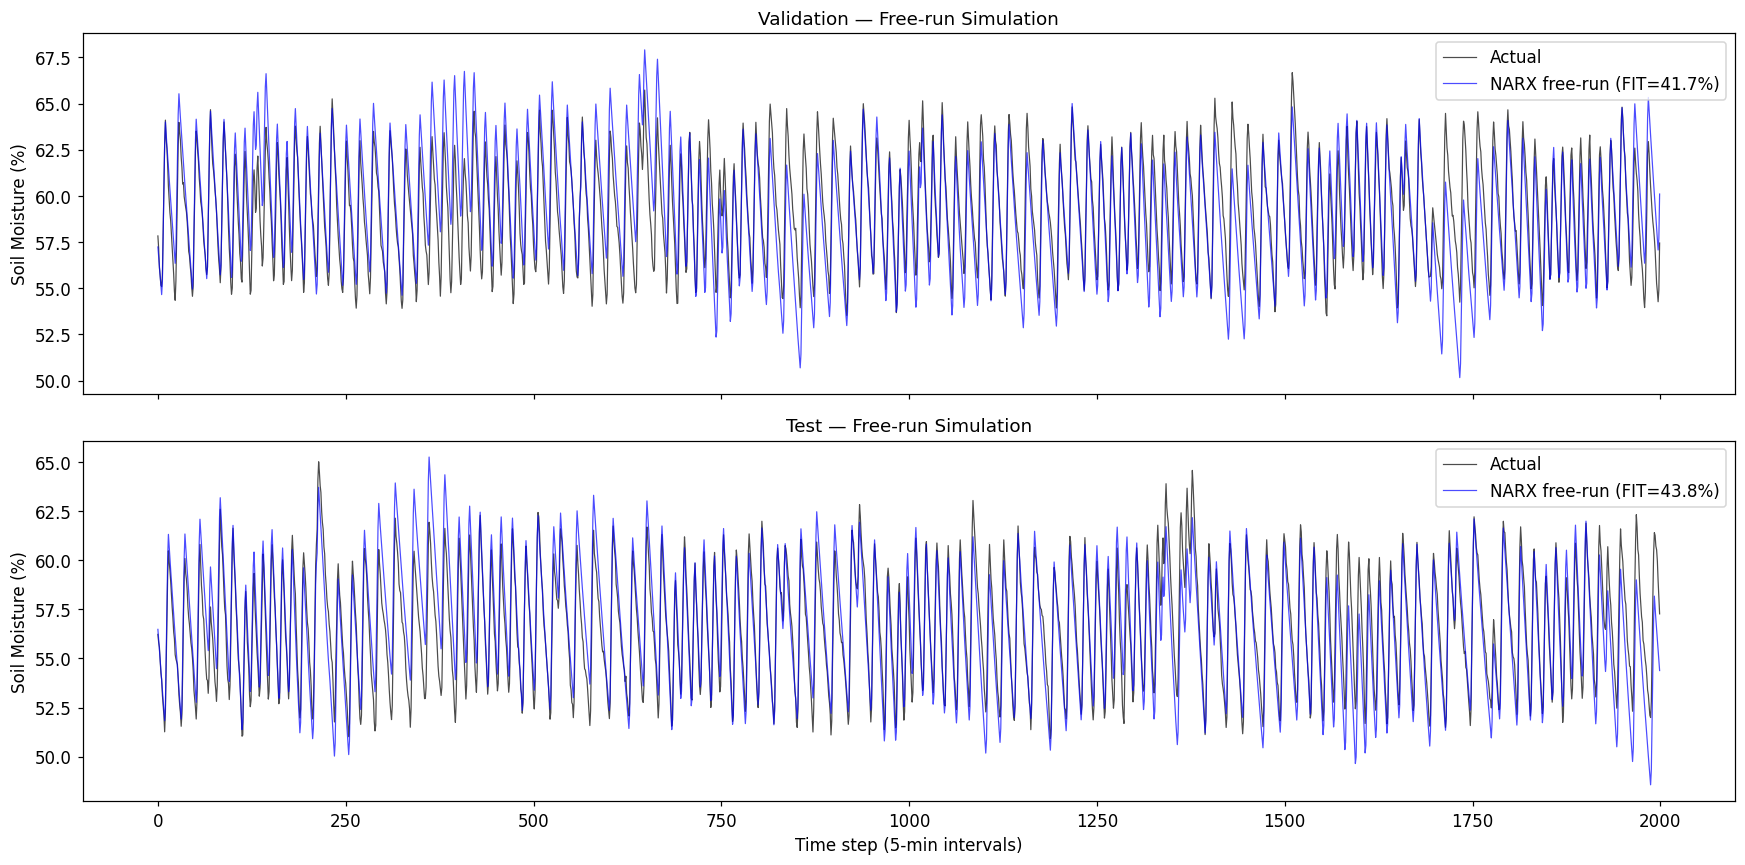

In [12]:
# === Visual: Free-run comparison ===
fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

for ax, ev, title in [(axes[0], eval_val, 'Validation'), (axes[1], eval_test, 'Test')]:
    n_show = min(2000, len(ev['arrays']['y_true_sim']))
    ax.plot(ev['arrays']['y_true_sim'][:n_show], label='Actual', color='black', linewidth=0.8, alpha=0.7)
    ax.plot(ev['arrays']['y_pred_sim'][:n_show], label=f'NARX free-run (FIT={ev["metrics_sim"]["FIT"]:.1f}%)',
            color='blue', linewidth=0.8, alpha=0.7)
    ax.set_title(f'{title} — Free-run Simulation')
    ax.set_ylabel('Soil Moisture (%)')
    ax.legend(loc='upper right')

axes[1].set_xlabel('Time step (5-min intervals)')
plt.tight_layout()
plt.show()

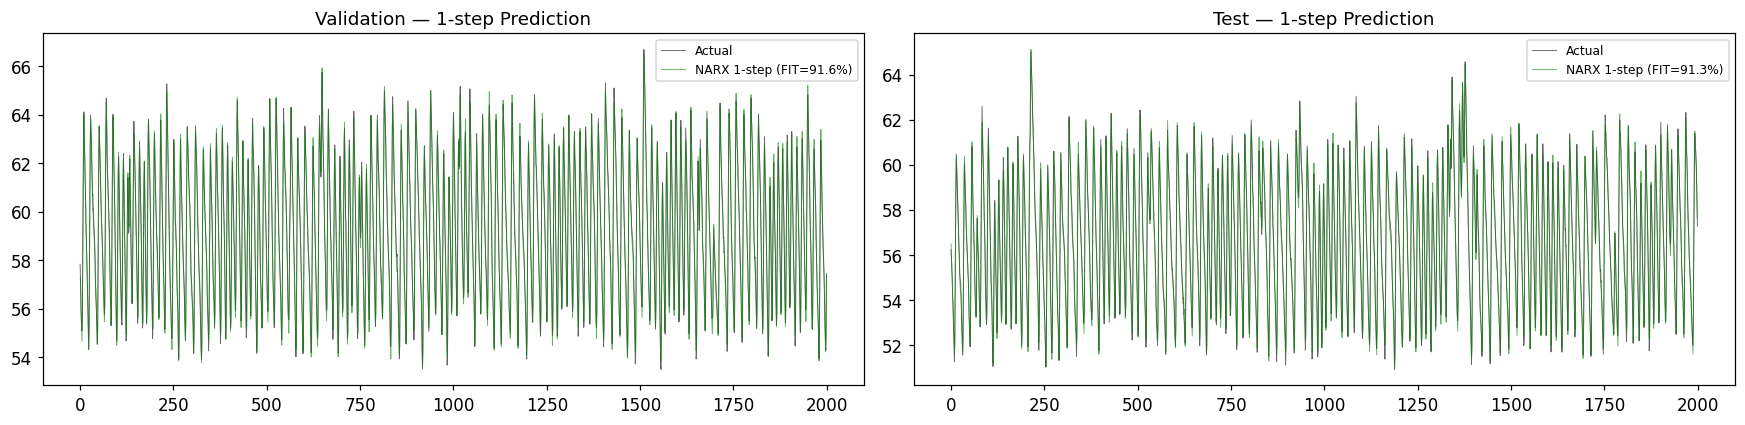

In [13]:
# === Visual: 1-step prediction quality ===
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

for ax, ev, title in [(axes[0], eval_val, 'Validation'), (axes[1], eval_test, 'Test')]:
    n_show = min(2000, len(ev['arrays']['y_true_1step']))
    ax.plot(ev['arrays']['y_true_1step'][:n_show], label='Actual', color='black', linewidth=0.6, alpha=0.6)
    ax.plot(ev['arrays']['y_pred_1step'][:n_show], label=f'NARX 1-step (FIT={ev["metrics_1step"]["FIT"]:.1f}%)',
            color='green', linewidth=0.6, alpha=0.6)
    ax.set_title(f'{title} — 1-step Prediction')
    ax.legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.show()

In [14]:
# === Improvement analysis ===
for ev, split in [(eval_val, 'Validation'), (eval_test, 'Test')]:
    narx_fit = ev['metrics_sim']['FIT']
    arx_fit = ev.get('arx_baseline_sim', {}).get('FIT', float('nan'))
    narx_1s = ev['metrics_1step']['FIT']
    arx_1s = ev.get('arx_baseline_1step', {}).get('FIT', float('nan'))
    print(f'{split}:')
    print(f'  1-step FIT:  NARX={narx_1s:.3f}%  ARX={arx_1s:.3f}%  Δ={narx_1s-arx_1s:+.3f}')
    print(f'  Free-run FIT: NARX={narx_fit:.3f}%  ARX={arx_fit:.3f}%  Δ={narx_fit-arx_fit:+.3f}')

display_research_note('Performance analysis', [
    'NARX 1-step FIT may be slightly higher than ARX due to additional polynomial features.',
    'Free-run FIT improvement depends on whether polynomial terms help stabilize long-horizon recursion.',
    'Since the generator is LINEAR, large NARX improvements are not expected — this confirms the baseline is sound.',
    'The simulation_clip at (0, 100) prevents divergence that extra parameters might cause.',
])

Validation:
  1-step FIT:  NARX=91.638%  ARX=91.641%  Δ=-0.002
  Free-run FIT: NARX=41.703%  ARX=42.959%  Δ=-1.256
Test:
  1-step FIT:  NARX=91.347%  ARX=91.349%  Δ=-0.002
  Free-run FIT: NARX=43.786%  ARX=43.875%  Δ=-0.089


### Performance analysis

- NARX 1-step FIT may be slightly higher than ARX due to additional polynomial features.
- Free-run FIT improvement depends on whether polynomial terms help stabilize long-horizon recursion.
- Since the generator is LINEAR, large NARX improvements are not expected — this confirms the baseline is sound.
- The simulation_clip at (0, 100) prevents divergence that extra parameters might cause.


## 8. ARX vs NARX — Detailed Comparison

In [15]:
# Side-by-side comparison table
comp_rows = []
for ev, split in [(eval_val, 'Validation'), (eval_test, 'Test')]:
    narx_m1 = ev['metrics_1step']
    narx_ms = ev['metrics_sim']
    arx_m1 = ev.get('arx_baseline_1step', {})
    arx_ms = ev.get('arx_baseline_sim', {})
    
    for metric_key, metric_label in [('FIT', 'FIT (%)'), ('RMSE', 'RMSE'), ('R2', 'R²'), ('MAE', 'MAE')]:
        comp_rows.append({
            'Split': split,
            'Metric': metric_label,
            'ARX 1-step': arx_m1.get(metric_key, float('nan')),
            'NARX 1-step': narx_m1.get(metric_key, float('nan')),
            'ARX Free-run': arx_ms.get(metric_key, float('nan')),
            'NARX Free-run': narx_ms.get(metric_key, float('nan')),
        })

comp_df = pd.DataFrame(comp_rows)
display(comp_df.round(4))

,Split,Metric,ARX 1-step,NARX 1-step,ARX Free-run,NARX Free-run
0,Validation,FIT (%),91.6406,91.6384,42.9588,41.7032
1,Validation,RMSE,0.2510,0.2510,1.7124,1.7501
2,Validation,R²,0.9930,0.9930,0.6746,0.6601
3,Validation,MAE,0.2004,0.2005,1.3658,1.3959
4,Test,FIT (%),91.3491,91.3468,43.8749,43.7858
5,Test,RMSE,0.2520,0.2520,1.6347,1.6373
6,Test,R²,0.9925,0.9925,0.6850,0.6840
7,Test,MAE,0.2006,0.2007,1.2976,1.2995


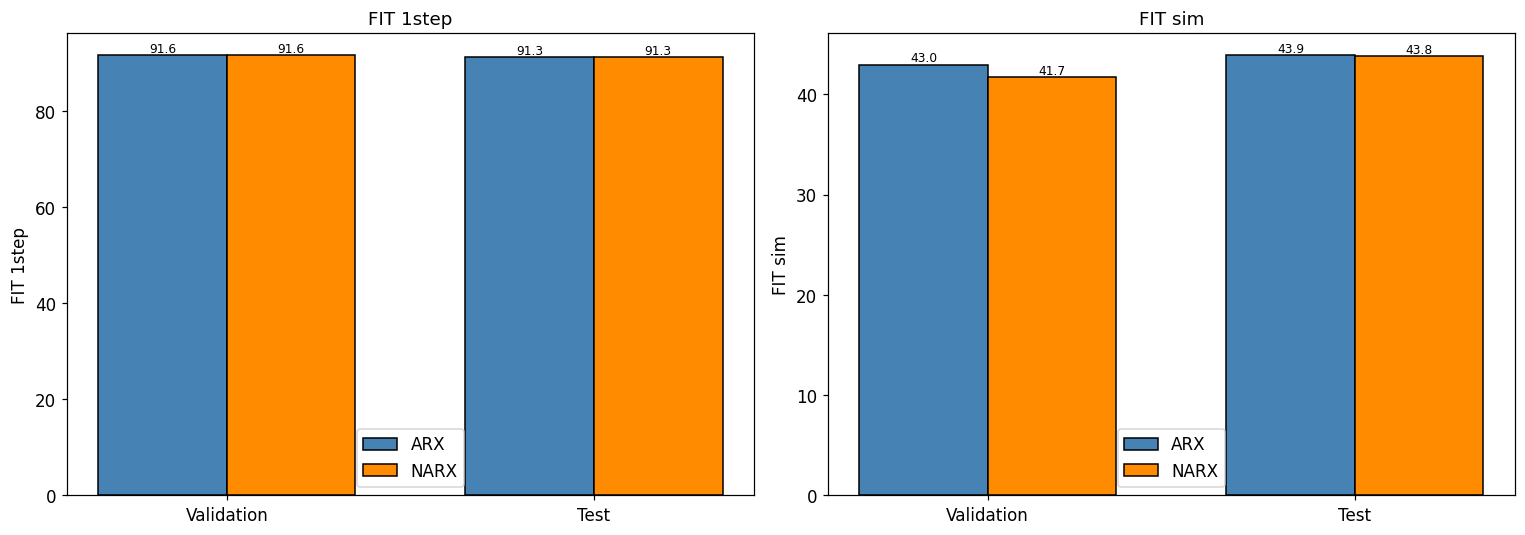

In [16]:
# Visual comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

metrics_to_plot = ['FIT_1step', 'FIT_sim']
for ax, metric in zip(axes, metrics_to_plot):
    val_narx = perf_df[(perf_df['Model']=='NARX') & (perf_df['Split']=='Validation')][metric].values[0]
    val_arx = perf_df[(perf_df['Model']=='ARX') & (perf_df['Split']=='Validation')][metric].values[0]
    test_narx = perf_df[(perf_df['Model']=='NARX') & (perf_df['Split']=='Test')][metric].values[0]
    test_arx = perf_df[(perf_df['Model']=='ARX') & (perf_df['Split']=='Test')][metric].values[0]
    
    x = np.arange(2)
    width = 0.35
    ax.bar(x - width/2, [val_arx, test_arx], width, label='ARX', color='steelblue', edgecolor='black')
    ax.bar(x + width/2, [val_narx, test_narx], width, label='NARX', color='darkorange', edgecolor='black')
    ax.set_xticks(x)
    ax.set_xticklabels(['Validation', 'Test'])
    ax.set_ylabel(metric.replace('_', ' '))
    ax.set_title(metric.replace('_', ' '))
    ax.legend()
    # Value labels
    for bar_group in [ax.containers[0], ax.containers[1]]:
        ax.bar_label(bar_group, fmt='%.1f', fontsize=8)

plt.tight_layout()
plt.show()

## 9. Residual Diagnostics

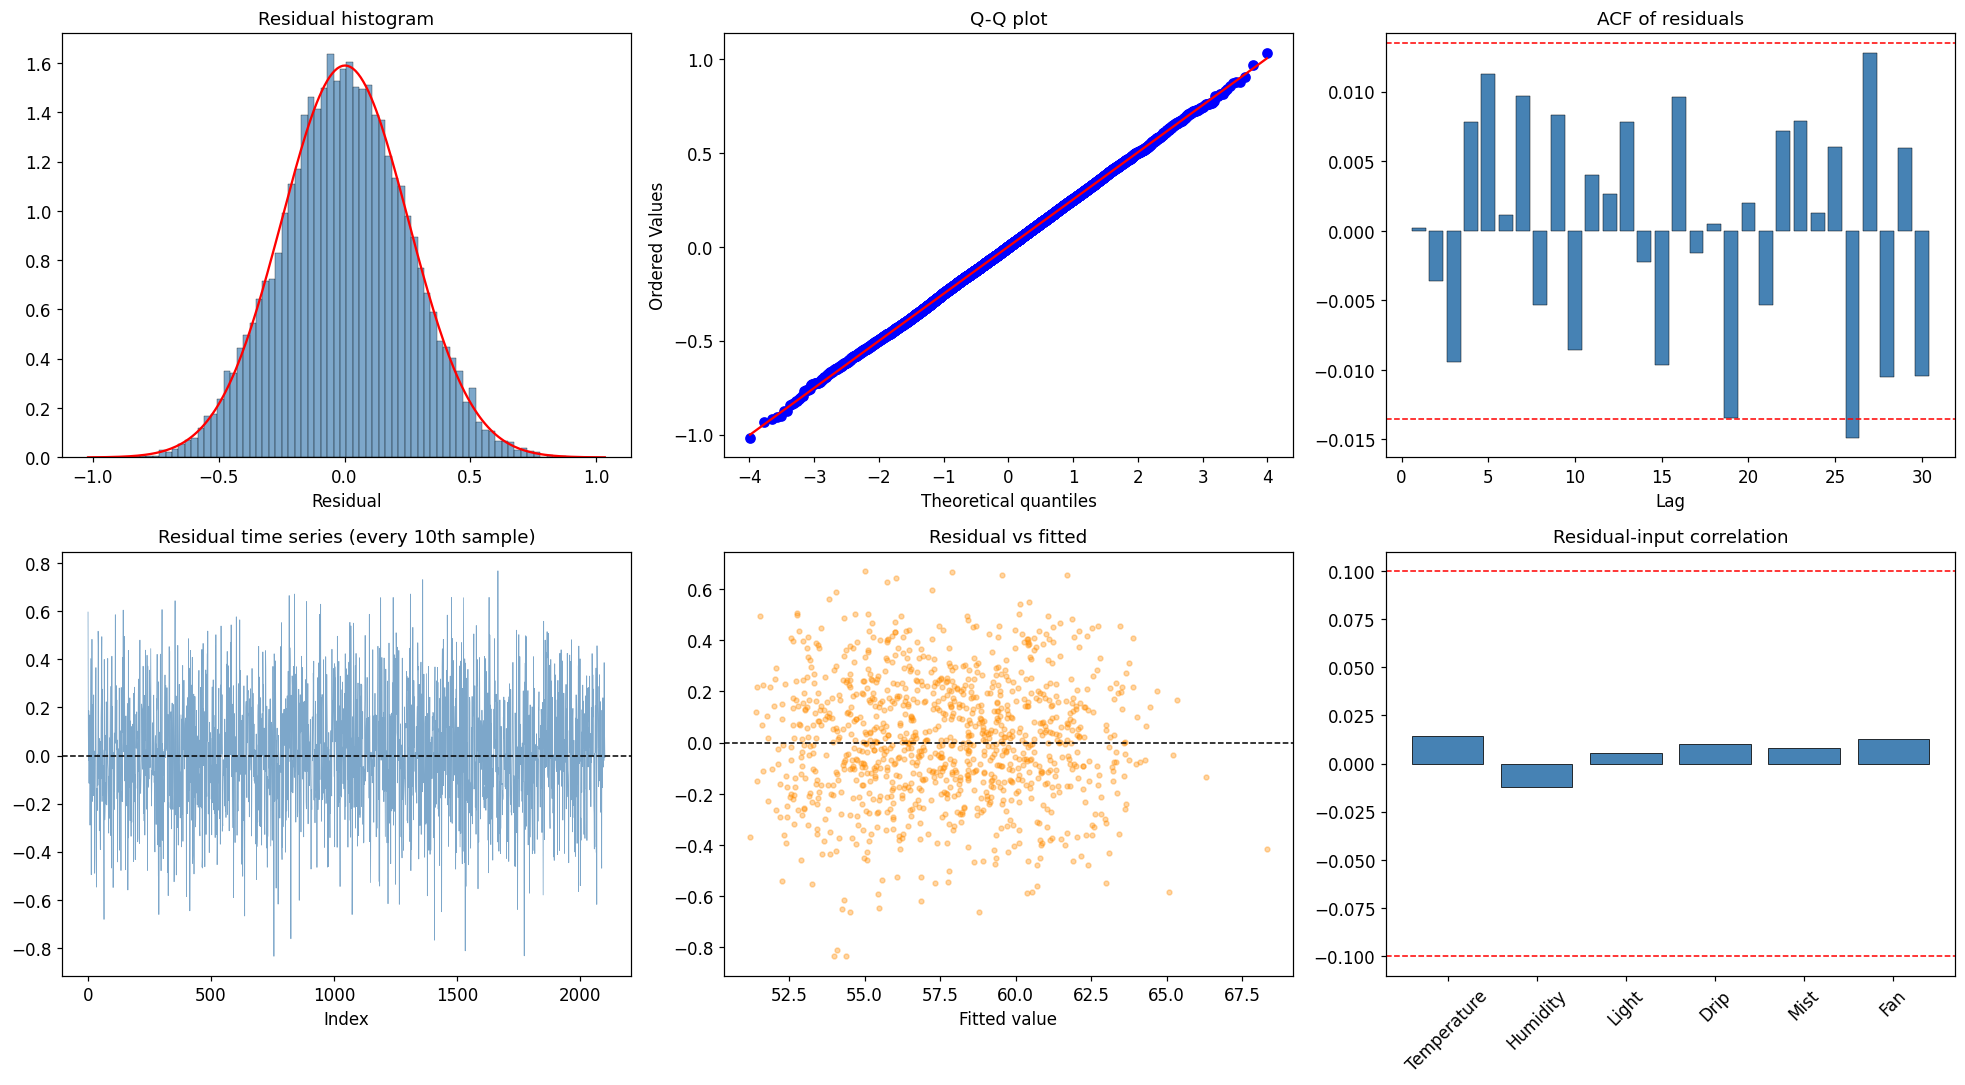

### Residual panel interpretation

- Max |residual-input correlation|: 0.0144
- Values near zero confirm polynomial features did not introduce spurious correlations.
- Q-Q plot and histogram assess near-Gaussianity of residuals.
- Residual-vs-fitted scatter checks heteroskedasticity.


In [17]:
# Residual diagnostics panel (6 subplots) — Validation set
val_resid = eval_val['arrays']['y_true_1step'] - eval_val['arrays']['y_pred_1step']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# (0,0) Histogram
axes[0, 0].hist(val_resid, bins=80, density=True, color='steelblue', edgecolor='black', linewidth=0.3, alpha=0.7)
xg = np.linspace(val_resid.min(), val_resid.max(), 200)
axes[0, 0].plot(xg, stats.norm.pdf(xg, val_resid.mean(), val_resid.std()), 'r-', linewidth=1.5)
axes[0, 0].set_title('Residual histogram')
axes[0, 0].set_xlabel('Residual')

# (0,1) Q-Q plot
stats.probplot(val_resid, dist='norm', plot=axes[0, 1])
axes[0, 1].set_title('Q-Q plot')

# (0,2) ACF
max_acf_lag = 30
acf_vals = [np.corrcoef(val_resid[lag:], val_resid[:-lag])[0, 1] for lag in range(1, max_acf_lag + 1)]
axes[0, 2].bar(range(1, max_acf_lag + 1), acf_vals, color='steelblue', edgecolor='black', linewidth=0.3)
ci_bound = 1.96 / np.sqrt(len(val_resid))
axes[0, 2].axhline(ci_bound, color='red', linestyle='--', linewidth=1)
axes[0, 2].axhline(-ci_bound, color='red', linestyle='--', linewidth=1)
axes[0, 2].set_title('ACF of residuals')
axes[0, 2].set_xlabel('Lag')

# (1,0) Residual time series
axes[1, 0].plot(val_resid[::10], linewidth=0.5, color='steelblue', alpha=0.7)
axes[1, 0].axhline(0, color='black', linestyle='--', linewidth=1)
axes[1, 0].set_title('Residual time series (every 10th sample)')
axes[1, 0].set_xlabel('Index')

# (1,1) Residual vs Fitted
axes[1, 1].scatter(eval_val['arrays']['y_pred_1step'][::20], val_resid[::20],
                    s=10, alpha=0.35, color='darkorange')
axes[1, 1].axhline(0, color='black', linestyle='--', linewidth=1)
axes[1, 1].set_title('Residual vs fitted')
axes[1, 1].set_xlabel('Fitted value')

# (1,2) Residual-Input correlation
max_lag_offset = max(NARX_CONFIG.na, NARX_CONFIG.nb + NARX_CONFIG.nk - 1)
n_min = min(len(val_resid), len(df_val) - max_lag_offset)
input_cc = []
for col in NARX_CONFIG.input_cols:
    u_vals = df_val[col].astype(float).to_numpy()[max_lag_offset:max_lag_offset + n_min]
    cc = float(np.corrcoef(val_resid[:n_min], u_vals[:n_min])[0, 1])
    input_cc.append(cc)

axes[1, 2].bar(list(NARX_CONFIG.input_cols), input_cc, color='steelblue', edgecolor='black', linewidth=0.5)
axes[1, 2].axhline(0.10, color='red', linestyle='--', linewidth=1)
axes[1, 2].axhline(-0.10, color='red', linestyle='--', linewidth=1)
axes[1, 2].set_title('Residual-input correlation')
axes[1, 2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

display_research_note('Residual panel interpretation', [
    f'Max |residual-input correlation|: {float(np.max(np.abs(input_cc))):.4f}',
    'Values near zero confirm polynomial features did not introduce spurious correlations.',
    'Q-Q plot and histogram assess near-Gaussianity of residuals.',
    'Residual-vs-fitted scatter checks heteroskedasticity.',
])

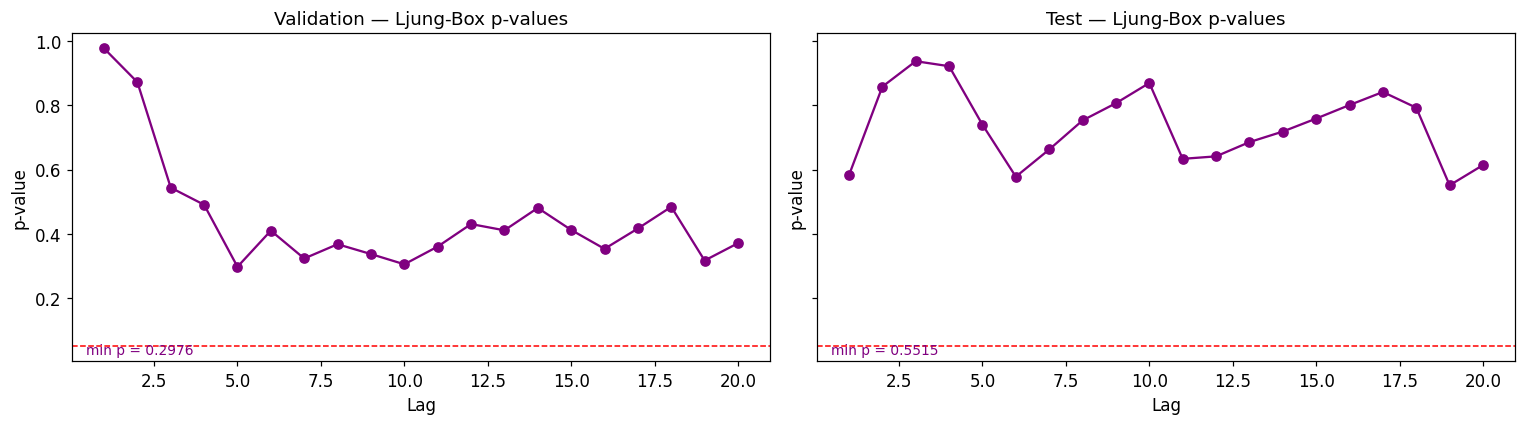

Validation: min p-value = 0.2976 → PASS ✅
Test: min p-value = 0.5515 → PASS ✅


### Ljung-Box interpretation

- p-values above 0.05 for all lags → no evidence of remaining serial correlation.
- This confirms the NARX model has captured the available linear structure.
- Comparing with ARX: if both pass, the polynomial terms do not degrade residual quality.


In [18]:
# === Ljung-Box test ===
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)

for ax, ev, title in [(axes[0], eval_val, 'Validation'), (axes[1], eval_test, 'Test')]:
    resid = ev['arrays']['y_true_1step'] - ev['arrays']['y_pred_1step']
    lb = acorr_ljungbox(resid.astype(float), lags=20, return_df=True)
    ax.plot(lb.index, lb['lb_pvalue'], marker='o', color='purple')
    ax.axhline(0.05, color='red', linestyle='--', linewidth=1)
    ax.set_title(f'{title} — Ljung-Box p-values')
    ax.set_xlabel('Lag')
    ax.set_ylabel('p-value')
    min_p = float(lb['lb_pvalue'].min())
    ax.annotate(f'min p = {min_p:.4f}', xy=(0.02, 0.02), xycoords='axes fraction',
                fontsize=9, color='purple')

plt.tight_layout()
plt.show()

# Summary
for ev, title in [(eval_val, 'Validation'), (eval_test, 'Test')]:
    resid = ev['arrays']['y_true_1step'] - ev['arrays']['y_pred_1step']
    lb = acorr_ljungbox(resid.astype(float), lags=20, return_df=True)
    min_p = float(lb['lb_pvalue'].min())
    passes = min_p > 0.05
    print(f'{title}: min p-value = {min_p:.4f} → {"PASS ✅" if passes else "FAIL ❌"}')

display_research_note('Ljung-Box interpretation', [
    'p-values above 0.05 for all lags → no evidence of remaining serial correlation.',
    'This confirms the NARX model has captured the available linear structure.',
    'Comparing with ARX: if both pass, the polynomial terms do not degrade residual quality.',
])

## 10. Model Structure Search

In [19]:
# Search over different NARX configurations
selection_df = narx_model_selection(
    df_train=df_train,
    df_val=df_val,
    base_config=NARX_CONFIG,
    na_list=[1, 2, 3],
    nb_list=[1, 2],
    nk_list=[1],
    degree_list=[1, 2],  # 1=linear (ARX equivalent), 2=quadratic
    cross_modes=['selective'],
)

print(f'Searched {len(selection_df)} configurations.')
print(f'\nTop 10 by free-run RMSE:')
display(selection_df.head(10).round(4))

Searched 12 configurations.

Top 10 by free-run RMSE:


,na,nb,nk,degree,cross_mode,n_params,RMSE_1step,FIT_1step,R2_1step,AIC_1step,BIC_1step,RMSE_sim,FIT_sim,R2_sim
0,3,1,1,2,selective,34,0.4043,86.5336,0.9819,-38006.7542,-37736.3428,1.3643,54.5565,0.7935
1,2,1,1,1,selective,9,0.4188,86.0493,0.9805,-36573.8030,-36502.2231,1.3659,54.5018,0.7930
2,2,1,1,2,selective,26,0.4118,86.2827,0.9812,-37249.3601,-37042.5737,1.3841,53.8967,0.7874
3,3,1,1,1,selective,10,0.4100,86.3429,0.9813,-37463.4036,-37383.8709,1.3919,53.6370,0.7850
4,1,2,1,1,selective,14,0.2514,91.6274,0.9930,-58030.1804,-57918.8339,1.5899,47.0393,0.7195
5,1,2,1,2,selective,33,0.2513,91.6277,0.9930,-57993.7149,-57731.2552,1.5988,46.7448,0.7164
6,3,2,1,1,selective,16,0.2509,91.6417,0.9930,-58093.9983,-57966.7458,1.7264,42.4948,0.6693
7,2,2,1,1,selective,15,0.2510,91.6405,0.9930,-58094.0504,-57974.7505,1.7266,42.4860,0.6692
8,3,2,1,2,selective,61,0.2510,91.6389,0.9930,-57990.0452,-57504.8953,1.7456,41.8554,0.6619
9,2,2,1,2,selective,47,0.2510,91.6384,0.9930,-58019.6150,-57645.8087,1.7501,41.7032,0.6601


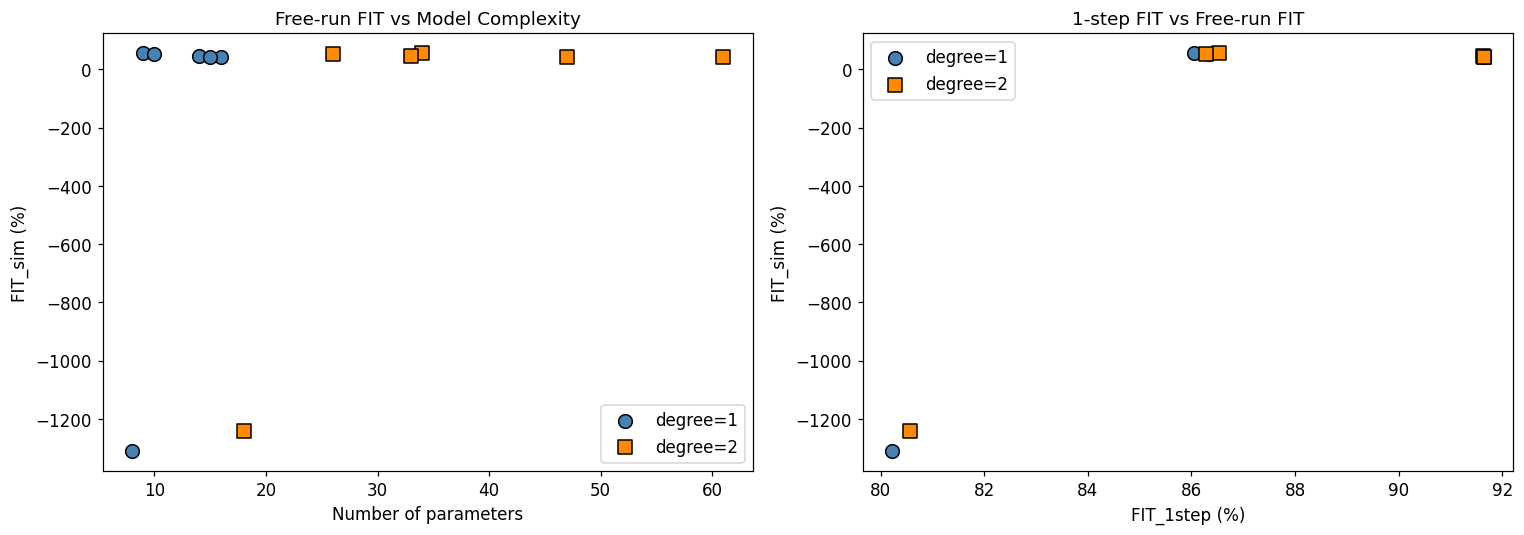

### Model search interpretation

- degree=1 configurations are equivalent to linear ARX models.
- degree=2 adds polynomial features — observe whether they consistently improve FIT_sim.
- If degree=2 does NOT significantly improve FIT_sim, the underlying system is well-approximated by a linear model.
- Higher n_params does not always mean better free-run — overfitting can worsen simulation stability.


In [20]:
# Visual: degree=1 vs degree=2 comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for degree, color, marker in [(1, 'steelblue', 'o'), (2, 'darkorange', 's')]:
    subset = selection_df[selection_df['degree'] == degree]
    if not subset.empty:
        axes[0].scatter(subset['n_params'], subset['FIT_sim'],
                        c=color, marker=marker, s=80, edgecolor='black',
                        label=f'degree={degree}', zorder=3)
        axes[1].scatter(subset['FIT_1step'], subset['FIT_sim'],
                        c=color, marker=marker, s=80, edgecolor='black',
                        label=f'degree={degree}', zorder=3)

axes[0].set_xlabel('Number of parameters')
axes[0].set_ylabel('FIT_sim (%)')
axes[0].set_title('Free-run FIT vs Model Complexity')
axes[0].legend()

axes[1].set_xlabel('FIT_1step (%)')
axes[1].set_ylabel('FIT_sim (%)')
axes[1].set_title('1-step FIT vs Free-run FIT')
axes[1].legend()

plt.tight_layout()
plt.show()

display_research_note('Model search interpretation', [
    'degree=1 configurations are equivalent to linear ARX models.',
    'degree=2 adds polynomial features — observe whether they consistently improve FIT_sim.',
    'If degree=2 does NOT significantly improve FIT_sim, the underlying system is well-approximated by a linear model.',
    'Higher n_params does not always mean better free-run — overfitting can worsen simulation stability.',
])

## 11. Conclusions

In [21]:
# Final summary
print('=' * 70)
print('NARX vs ARX — FINAL COMPARISON')
print('=' * 70)

for ev, split in [(eval_val, 'Validation'), (eval_test, 'Test')]:
    narx_1s = ev['metrics_1step']['FIT']
    narx_sim = ev['metrics_sim']['FIT']
    arx_1s = ev.get('arx_baseline_1step', {}).get('FIT', float('nan'))
    arx_sim = ev.get('arx_baseline_sim', {}).get('FIT', float('nan'))
    
    print(f'\n{split}:')
    print(f'  {"Metric":<15} {"ARX":>10} {"NARX":>10} {"Δ":>10}')
    print(f'  {"─"*45}')
    print(f'  {"FIT 1-step":<15} {arx_1s:>10.2f} {narx_1s:>10.2f} {narx_1s-arx_1s:>+10.2f}')
    print(f'  {"FIT free-run":<15} {arx_sim:>10.2f} {narx_sim:>10.2f} {narx_sim-arx_sim:>+10.2f}')
    print(f'  {"# params":<15} {len(theta_arx):>10} {len(theta_narx):>10}')

print()
sig_count = int(param_df['Significant (p<0.05)'].sum())
print(f'NARX significant parameters: {sig_count}/{len(theta_narx)}')
print(f'σ² reduction (NARX vs ARX):  {(1-sigma2_narx/sigma2_arx)*100:.2f}%')

display_research_note('Key findings', [
    'The polynomial NARX extends the linear ARX baseline with degree-2 features.',
    f'NARX uses {len(theta_narx)} parameters vs {len(theta_arx)} for ARX ({len(theta_narx)/len(theta_arx):.1f}x more).',
    'Since the data generator is inherently LINEAR, large improvements from polynomial terms are not expected.',
    'This experiment validates the ARX baseline: if NARX cannot significantly improve, the linear model is already capturing the available dynamics.',
    'For real-world non-linear greenhouse systems, NARX polynomial terms would likely provide meaningful improvement.',
    'Future work: test on REAL sensor data where non-linearities are present.',
])

NARX vs ARX — FINAL COMPARISON

Validation:
  Metric                 ARX       NARX          Δ
  ─────────────────────────────────────────────
  FIT 1-step           91.64      91.64      -0.00
  FIT free-run         42.96      41.70      -1.26
  # params                14         47

Test:
  Metric                 ARX       NARX          Δ
  ─────────────────────────────────────────────
  FIT 1-step           91.35      91.35      -0.00
  FIT free-run         43.87      43.79      -0.09
  # params                14         47

NARX significant parameters: 11/47
σ² reduction (NARX vs ARX):  0.01%


### Key findings

- The polynomial NARX extends the linear ARX baseline with degree-2 features.
- NARX uses 47 parameters vs 14 for ARX (3.4x more).
- Since the data generator is inherently LINEAR, large improvements from polynomial terms are not expected.
- This experiment validates the ARX baseline: if NARX cannot significantly improve, the linear model is already capturing the available dynamics.
- For real-world non-linear greenhouse systems, NARX polynomial terms would likely provide meaningful improvement.
- Future work: test on REAL sensor data where non-linearities are present.
